In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [2]:
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

In [3]:
nav['date'] = pd.to_datetime(nav['date'])

benchmark['date'] = pd.to_datetime(benchmark['date'])

In [4]:
print(nav.shape)

print(benchmark.shape)

print(nav.head())

(46000, 3)
(8050, 3)
   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474
2     119551 2022-01-05  54.6869
3     119551 2022-01-06  55.4550
4     119551 2022-01-07  55.3692


In [5]:
nav = nav.sort_values(
    ['amfi_code', 'date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

In [6]:
print(
    nav[
        ['amfi_code',
         'date',
         'nav',
         'daily_return']
    ].head(10)
)

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
5756     100016 2022-01-11  513.5542      0.005562
5757     100016 2022-01-12  512.3195     -0.002404
5758     100016 2022-01-13  510.2445     -0.004050
5759     100016 2022-01-14  514.3636      0.008073


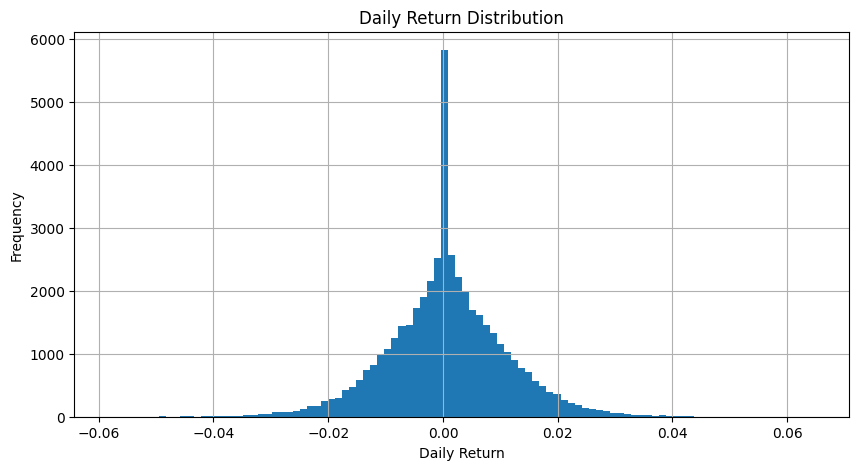

In [7]:
plt.figure(figsize=(10,5))

nav['daily_return'].hist(
    bins=100
)

plt.title(
    "Daily Return Distribution"
)

plt.xlabel(
    "Daily Return"
)

plt.ylabel(
    "Frequency"
)

plt.show()

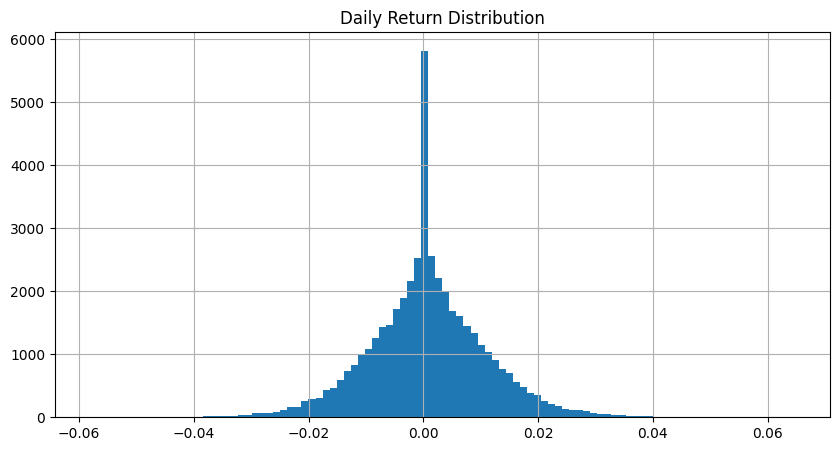

In [8]:
plt.figure(figsize=(10,5))

nav['daily_return'].hist(
    bins=100
)

plt.title(
    "Daily Return Distribution"
)

plt.savefig(
    "../reports/daily_return_distribution.png"
)

plt.show()

In [9]:
import os

print(
    os.listdir("../reports")
)

['aum_growth_by_fund_house.png', 'aum_market_share.png', 'average_nav.png', 'category_inflow_distribution.png', 'category_inflow_heatmap.png', 'daily_return_distribution.png', 'data_dictionary.md', 'equity_vs_debt_distribution.png', 'folio_growth.png', 'folio_growth_pct.png', 'fund_category_distribution.png', 'nav_correlation_matrix.png', 'nav_trend.png', 'quarterly_sip_trend.png', 'risk_category_distribution.png', 'sector_allocation_donut.png', 'sip_inflow_trend.png', 'top_fund_houses.png']


In [10]:
def cagr(start_nav, end_nav, years):

    return (
        (end_nav / start_nav)
        ** (1 / years) - 1
    ) * 100

In [11]:
cagr_table = []

for code in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == code
    ]

    start_nav = temp.iloc[0]['nav']

    end_nav = temp.iloc[-1]['nav']

    years = (
        temp.iloc[-1]['date']
        -
        temp.iloc[0]['date']
    ).days / 365

    cagr_value = cagr(
        start_nav,
        end_nav,
        years
    )

    cagr_table.append(
        [code, cagr_value]
    )

In [12]:
cagr_df = pd.DataFrame(
    cagr_table,
    columns=[
        'amfi_code',
        'cagr_pct'
    ]
)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.635246
1,100025,4.455091
2,100033,30.099704
3,101206,23.520489
4,101207,7.933121


In [13]:
cagr_df.to_csv(
    "../reports/cagr_table.csv",
    index=False
)

In [14]:
import os

print(
    os.listdir("../reports")
)

['aum_growth_by_fund_house.png', 'aum_market_share.png', 'average_nav.png', 'cagr_table.csv', 'category_inflow_distribution.png', 'category_inflow_heatmap.png', 'daily_return_distribution.png', 'data_dictionary.md', 'equity_vs_debt_distribution.png', 'folio_growth.png', 'folio_growth_pct.png', 'fund_category_distribution.png', 'nav_correlation_matrix.png', 'nav_trend.png', 'quarterly_sip_trend.png', 'risk_category_distribution.png', 'sector_allocation_donut.png', 'sip_inflow_trend.png', 'top_fund_houses.png']


In [15]:
rf = 0.065

In [16]:
sharpe_list = []

for code in nav['amfi_code'].unique():

    temp = nav[nav['amfi_code'] == code]

    annual_return = (
        temp['daily_return'].mean()
        * 252
    )

    annual_volatility = (
        temp['daily_return'].std()
        * np.sqrt(252)
    )

    sharpe = (
        annual_return - rf
    ) / annual_volatility

    sharpe_list.append(
        [code, sharpe]
    )

In [17]:
sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        'amfi_code',
        'sharpe_ratio'
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [18]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

In [19]:
sortino_list = []

for code in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == code
    ]

    downside = temp[
        temp['daily_return'] < 0
    ]

    downside_std = (
        downside['daily_return']
        .std()
        * np.sqrt(252)
    )

    annual_return = (
        temp['daily_return']
        .mean()
        * 252
    )

    sortino = (
        annual_return - rf
    ) / downside_std

    sortino_list.append(
        [code, sortino]
    )

In [20]:
sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [21]:
print(benchmark.columns)
print(benchmark.head())

Index(['date', 'index_name', 'close_value'], dtype='str')
        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05
3 2022-01-06    NIFTY50     17878.51
4 2022-01-07    NIFTY50     17759.15


In [22]:
nifty = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

nifty = nifty.sort_values('date')

nifty['benchmark_return'] = (
    nifty['close_value']
    .pct_change()
)

nifty.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
1,2022-01-04,NIFTY50,17689.64,0.011253
2,2022-01-05,NIFTY50,17835.05,0.008220
3,2022-01-06,NIFTY50,17878.51,0.002437
4,2022-01-07,NIFTY50,17759.15,-0.006676


In [23]:
alpha_beta_list = []

for code in nav['amfi_code'].unique():

    fund = nav[
        nav['amfi_code'] == code
    ][['date','daily_return']]

    merged = pd.merge(
        fund,
        nifty[['date','benchmark_return']],
        on='date'
    )

    merged = merged.dropna()

    slope, intercept, r, p, std = linregress(
        merged['benchmark_return'],
        merged['daily_return']
    )

    beta = slope

    alpha = intercept * 252

    alpha_beta_list.append(
        [code, alpha, beta]
    )

In [24]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_list,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.036221,-0.025909
1,100025,0.043189,-0.016176
2,100033,0.272343,-0.011200
3,101206,0.213945,0.033814
4,101207,0.108205,-0.059856


In [25]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [26]:
drawdown_list = []

for code in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == code
    ].copy()

    temp['running_max'] = (
        temp['nav'].cummax()
    )

    temp['drawdown'] = (
        temp['nav']
        /
        temp['running_max']
        - 1
    )

    max_dd = temp[
        'drawdown'
    ].min()

    drawdown_list.append(
        [code, max_dd]
    )

In [27]:
drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [28]:
scorecard = cagr_df.merge(
    sharpe_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    drawdown_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    sortino_df,
    on='amfi_code'
)

In [29]:
scorecard['cagr_rank'] = scorecard[
    'cagr_pct'
].rank(
    ascending=False
)

scorecard['sharpe_rank'] = scorecard[
    'sharpe_ratio'
].rank(
    ascending=False
)

scorecard['alpha_rank'] = scorecard[
    'alpha'
].rank(
    ascending=False
)

scorecard['drawdown_rank'] = scorecard[
    'max_drawdown'
].rank(
    ascending=False
)

scorecard['sortino_rank'] = scorecard[
    'sortino_ratio'
].rank(
    ascending=False
)

In [30]:
scorecard['fund_score'] = (

    scorecard['cagr_rank'] * 0.30 +

    scorecard['sharpe_rank'] * 0.25 +

    scorecard['alpha_rank'] * 0.20 +

    scorecard['drawdown_rank'] * 0.15 +

    scorecard['sortino_rank'] * 0.10

)

In [31]:
scorecard.sort_values(
    'fund_score'
).head(10)

,amfi_code,cagr_pct,sharpe_ratio,alpha,beta,max_drawdown,sortino_ratio,cagr_rank,sharpe_rank,alpha_rank,drawdown_rank,sortino_rank,fund_score
34,148567,30.949920,1.448291,0.271150,-0.028133,-0.112657,2.385644,5.0,1.0,7.0,8.0,1.0,4.45
30,120843,30.883326,1.306744,0.272784,-0.008737,-0.129740,2.364320,6.0,2.0,5.0,13.0,2.0,5.45
36,148569,31.924486,1.234930,0.283473,-0.010201,-0.163967,2.146914,4.0,3.0,4.0,21.0,3.0,6.20
25,120505,32.801599,1.180101,0.293014,-0.017391,-0.181885,2.029353,1.0,5.0,3.0,25.0,5.0,6.40
2,100033,30.099704,1.093699,0.272343,-0.011200,-0.162172,1.829134,7.0,7.0,6.0,20.0,8.0,8.85
19,119551,25.784921,1.208267,0.232196,-0.056045,-0.150124,2.140267,10.0,4.0,10.0,17.0,4.0,8.95
38,149323,29.558105,1.132122,0.265836,0.003479,-0.172481,1.875101,8.0,6.0,8.0,22.0,6.0,9.40
3,101206,23.520489,1.027213,0.213945,0.033814,-0.112916,1.799563,12.0,9.0,12.0,9.0,10.0,10.60
21,119598,32.398084,0.945308,0.301114,0.074266,-0.287060,1.675317,2.0,14.0,1.0,36.0,12.0,10.90
39,149324,32.262108,0.949796,0.298179,0.132608,-0.311719,1.619793,3.0,13.0,2.0,37.0,14.0,11.50


In [32]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [33]:
import os

print(os.listdir("../reports"))

['alpha_beta.csv', 'aum_growth_by_fund_house.png', 'aum_market_share.png', 'average_nav.png', 'cagr_table.csv', 'category_inflow_distribution.png', 'category_inflow_heatmap.png', 'daily_return_distribution.png', 'data_dictionary.md', 'equity_vs_debt_distribution.png', 'folio_growth.png', 'folio_growth_pct.png', 'fund_category_distribution.png', 'fund_scorecard.csv', 'nav_correlation_matrix.png', 'nav_trend.png', 'quarterly_sip_trend.png', 'risk_category_distribution.png', 'sector_allocation_donut.png', 'sharpe_ratio.csv', 'sip_inflow_trend.png', 'top_fund_houses.png']


In [34]:
benchmark['index_name'].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [35]:
top5 = scorecard.sort_values(
    'fund_score'
).head(5)['amfi_code'].tolist()

print(top5)

[148567, 120843, 148569, 120505, 100033]


In [36]:
comparison = pd.DataFrame()

for code in top5:

    temp = nav[
        nav['amfi_code']==code
    ][['date','nav']].copy()

    temp = temp.sort_values('date')

    temp[str(code)] = (
        temp['nav']
        /
        temp['nav'].iloc[0]
    ) * 100

    temp = temp[['date',str(code)]]

    if comparison.empty:
        comparison=temp
    else:
        comparison=comparison.merge(
            temp,
            on='date'
        )

In [37]:
comparison.head()


,date,148567,120843,148569,120505,100033
0,2022-01-03,100.000000,100.000000,100.000000,100.000000,100.000000
1,2022-01-04,101.931776,101.815956,100.837780,98.010039,98.667204
2,2022-01-05,101.530219,100.563179,102.379946,100.984824,98.234425
3,2022-01-06,102.737597,101.418866,102.468297,100.488327,97.726862
4,2022-01-07,102.790549,100.052091,102.588525,101.458505,97.165097


In [38]:
nifty50 = benchmark[
    benchmark['index_name']=='NIFTY50'
].copy()

nifty50['NIFTY50'] = (
    nifty50['close_value']
    /
    nifty50['close_value'].iloc[0]
)*100

comparison = comparison.merge(
    nifty50[['date','NIFTY50']],
    on='date'
)

In [39]:
nifty100 = benchmark[
    benchmark['index_name']=='NIFTY100'
].copy()

nifty100['NIFTY100'] = (
    nifty100['close_value']
    /
    nifty100['close_value'].iloc[0]
)*100

comparison = comparison.merge(
    nifty100[['date','NIFTY100']],
    on='date'
)

In [40]:
comparison.head()

,date,148567,120843,148569,120505,100033,NIFTY50,NIFTY100
0,2022-01-03,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1,2022-01-04,101.931776,101.815956,100.837780,98.010039,98.667204,101.125321,98.645985
2,2022-01-05,101.530219,100.563179,102.379946,100.984824,98.234425,101.956578,99.040906
3,2022-01-06,102.737597,101.418866,102.468297,100.488327,97.726862,102.205023,98.750214
4,2022-01-07,102.790549,100.052091,102.588525,101.458505,97.165097,101.522684,99.357529


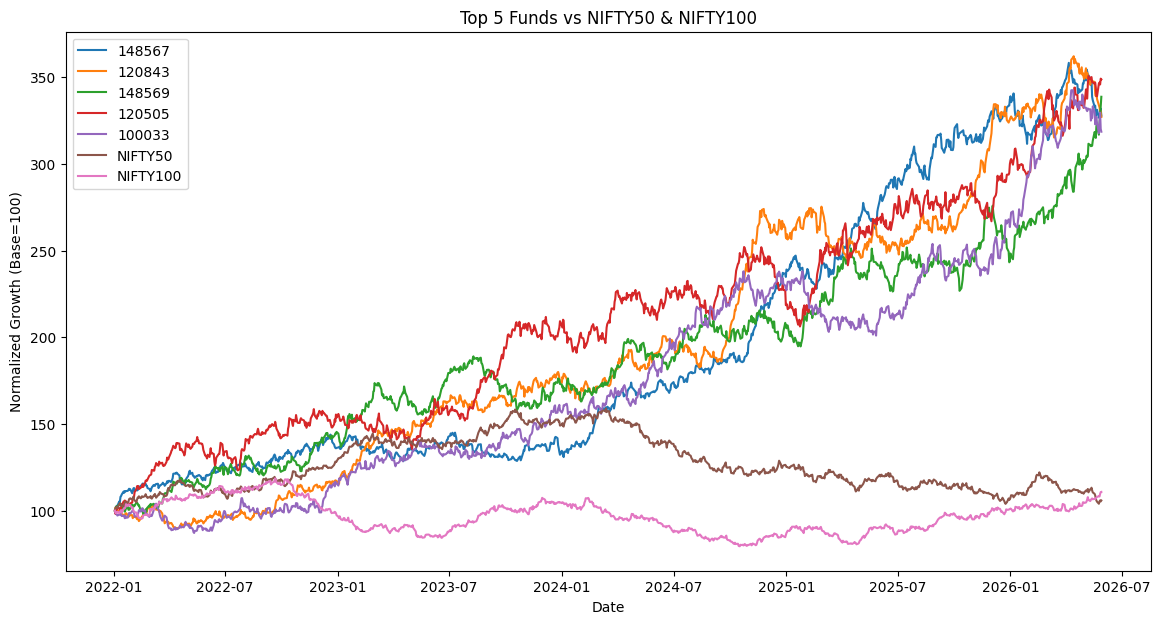

In [41]:
plt.figure(figsize=(14,7))

for col in comparison.columns[1:]:

    plt.plot(
        comparison['date'],
        comparison[col],
        label=str(col)
    )

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100"
)

plt.xlabel("Date")
plt.ylabel("Normalized Growth (Base=100)")

plt.legend()

plt.show()

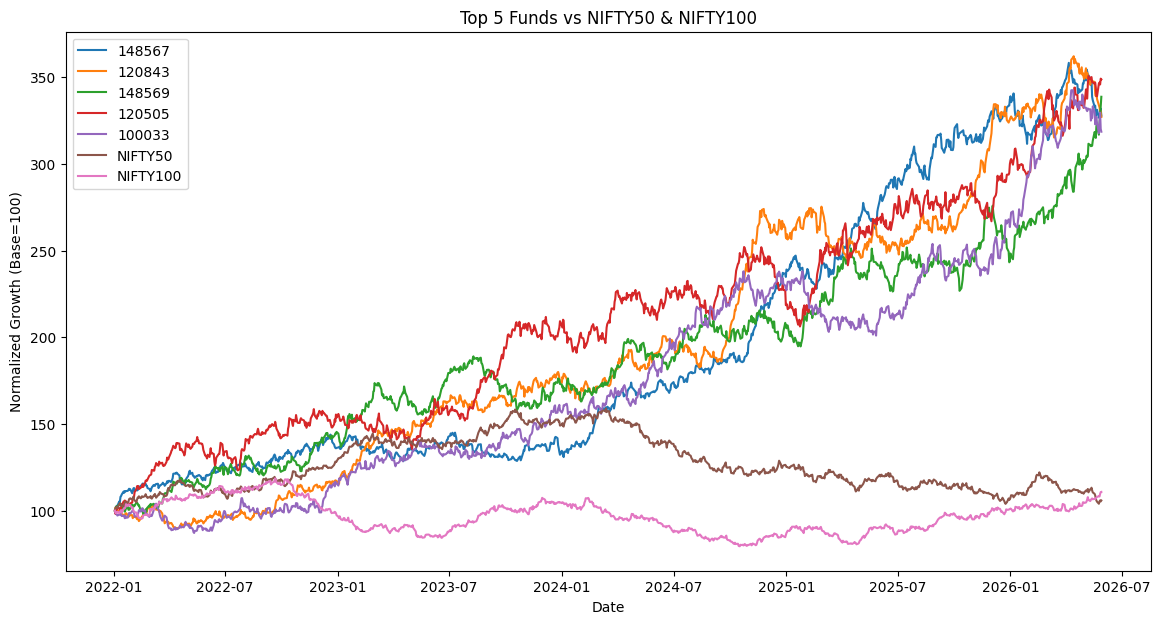

In [42]:
plt.figure(figsize=(14,7))

for col in comparison.columns[1:]:

    plt.plot(
        comparison['date'],
        comparison[col],
        label=str(col)
    )

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100"
)

plt.xlabel("Date")
plt.ylabel("Normalized Growth (Base=100)")

plt.legend()

plt.savefig(
    "../reports/benchmark_comparison.png"
)

plt.show()

In [43]:
import os
print(os.listdir("../reports"))

['alpha_beta.csv', 'aum_growth_by_fund_house.png', 'aum_market_share.png', 'average_nav.png', 'benchmark_comparison.png', 'cagr_table.csv', 'category_inflow_distribution.png', 'category_inflow_heatmap.png', 'daily_return_distribution.png', 'data_dictionary.md', 'equity_vs_debt_distribution.png', 'folio_growth.png', 'folio_growth_pct.png', 'fund_category_distribution.png', 'fund_scorecard.csv', 'nav_correlation_matrix.png', 'nav_trend.png', 'quarterly_sip_trend.png', 'risk_category_distribution.png', 'sector_allocation_donut.png', 'sharpe_ratio.csv', 'sip_inflow_trend.png', 'top_fund_houses.png']


In [44]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)



NameError: name 'tracking_error_df' is not defined

In [45]:
tracking_errors = []

benchmark_returns = (
    comparison['NIFTY50']
    .pct_change()
)

for code in top5:

    fund_returns = (
        comparison[str(code)]
        .pct_change()
    )

    tracking_error = (
        (fund_returns - benchmark_returns)
        .std()
        * np.sqrt(252)
    )

    tracking_errors.append(
        [code, tracking_error]
    )

tracking_error_df = pd.DataFrame(
    tracking_errors,
    columns=[
        'amfi_code',
        'tracking_error'
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,148567,0.193996
1,120843,0.205148
2,148569,0.219389
3,120505,0.233124
4,100033,0.229755


In [46]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

In [47]:
import os
print(sorted(os.listdir("../reports")))

['alpha_beta.csv', 'aum_growth_by_fund_house.png', 'aum_market_share.png', 'average_nav.png', 'benchmark_comparison.png', 'cagr_table.csv', 'category_inflow_distribution.png', 'category_inflow_heatmap.png', 'daily_return_distribution.png', 'data_dictionary.md', 'equity_vs_debt_distribution.png', 'folio_growth.png', 'folio_growth_pct.png', 'fund_category_distribution.png', 'fund_scorecard.csv', 'nav_correlation_matrix.png', 'nav_trend.png', 'quarterly_sip_trend.png', 'risk_category_distribution.png', 'sector_allocation_donut.png', 'sharpe_ratio.csv', 'sip_inflow_trend.png', 'top_fund_houses.png', 'tracking_error.csv']


In [48]:
print(fund_master.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')


In [49]:
expense = fund_master[
    ['amfi_code', 'expense_ratio_pct']
].copy()

scorecard = scorecard.merge(
    expense,
    on='amfi_code'
)

scorecard.head()

,amfi_code,cagr_pct,sharpe_ratio,alpha,beta,max_drawdown,sortino_ratio,cagr_rank,sharpe_rank,alpha_rank,drawdown_rank,sortino_rank,fund_score,expense_ratio_pct
0,100016,2.635246,-0.201517,0.036221,-0.025909,-0.247344,-0.351047,37.0,35.0,39.0,34.0,36.0,36.35,1.55
1,100025,4.455091,-0.567095,0.043189,-0.016176,-0.043083,-0.941821,36.0,39.0,38.0,4.0,39.0,32.65,0.56
2,100033,30.099704,1.093699,0.272343,-0.011200,-0.162172,1.829134,7.0,7.0,6.0,20.0,8.0,8.85,1.38
3,101206,23.520489,1.027213,0.213945,0.033814,-0.112916,1.799563,12.0,9.0,12.0,9.0,10.0,10.60,1.60
4,101207,7.933121,0.162661,0.108205,-0.059856,-0.354469,0.276644,27.0,28.0,27.0,38.0,28.0,29.00,1.53


In [50]:
print(scorecard.columns)

Index(['amfi_code', 'cagr_pct', 'sharpe_ratio', 'alpha', 'beta',
       'max_drawdown', 'sortino_ratio', 'cagr_rank', 'sharpe_rank',
       'alpha_rank', 'drawdown_rank', 'sortino_rank', 'fund_score',
       'expense_ratio_pct'],
      dtype='str')


In [51]:
scorecard['expense_rank'] = scorecard[
    'expense_ratio_pct'
].rank(
    ascending=True
)

In [52]:
scorecard['fund_score'] = (

    scorecard['cagr_rank'] * 0.30 +

    scorecard['sharpe_rank'] * 0.25 +

    scorecard['alpha_rank'] * 0.20 +

    scorecard['expense_rank'] * 0.15 +

    scorecard['drawdown_rank'] * 0.10

)

In [53]:
scorecard[
    ['amfi_code',
     'expense_ratio_pct',
     'expense_rank',
     'fund_score']
].head()

,amfi_code,expense_ratio_pct,expense_rank,fund_score
0,100016,1.55,32.0,35.850
1,100025,0.56,2.0,28.850
2,100033,1.38,17.0,9.600
3,101206,1.60,36.5,14.625
4,101207,1.53,28.5,28.575
